# 📈 규칙 기반 추세추종 (Rule-Based Trend Following)

## 문제 재정의
ML 예측(방향성·랭킹)은 일봉 기술지표만으로 **거래비용을 이기는 알파가 없음**을 확인했다 → [FINDINGS.md](../../docs/FINDINGS.md).
그 실험에서 반복해 드러난 사실: **모델이 결국 "모멘텀(추세)"을 재현**하고 있었다는 것.

그렇다면 블랙박스로 모멘텀을 근사하지 말고, **추세추종 규칙을 투명하게 + 비용·회전율 관리와 함께 직접** 구현하자.

## 왜 이게 더 정직한가
- **과적합/누출 없음** — 파라미터(200일선, 50/200 크로스, 12개월 모멘텀)는 수십 년 된 관습값이지 이 데이터에 맞춘 값이 아님. train/test 분리조차 불필요.
- **예측이 아니라 반응** — 미래를 맞히지 않는다. 오르는 추세엔 올라타고, 꺾이면 현금으로 빠진다.
- **역사적 엣지의 정체** — 추세추종의 실증적 이점은 "높은 수익"이 아니라 **최대낙폭(MDD) 축소 = 위기 방어(crisis alpha)**. 강한 상승 단일종목에선 Buy&Hold보다 수익이 낮을 수 있으나, 위험 대비(Sharpe)와 낙폭에서 이득.
- **낮은 회전율** — 레짐 전환은 드물어 거래가 적음 → 비용에 강함.

## 평가 원칙 (앞선 프로젝트의 교훈 그대로)
- 신호는 **t일 종가까지의 정보로만** 계산, **t+1일 체결**(룩어헤드 방지)
- **편도 거래비용**을 포지션 변경 시에만 차감
- **다자산**(지수 ETF + 대형주 + 금/채권)에 적용해 규칙의 **일관성** 확인
- 지표: CAGR · Sharpe · Sortino · **MaxDD** · Calmar · 시장노출시간 · 거래횟수
- 벤치마크: **Buy & Hold**

> ⚠️ 투자 자문이 아니며 교육/연구 목적입니다.

In [1]:
# =====================================================================
# ⚙️ Cell 1: 설정 & 임포트
# =====================================================================
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우 한글 폰트
except Exception:
    pass
plt.rcParams['axes.unicode_minus'] = False

# 자산 유니버스: 지수 ETF + 대형주 + 금/채권 (추세추종은 다양한 자산에서 검증)
TICKERS = ['SPY', 'QQQ', 'AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM', 'GLD', 'TLT']

START = '2010-01-01'
END   = None            # None -> 오늘까지
COST  = 0.0005          # 편도 거래비용 0.05% (ETF/대형주 현실적 수준)
ANN   = 252             # 연 거래일

print(f'자산 {len(TICKERS)}개 | 기간 {START}~현재 | 편도비용 {COST*100:.2f}%')

자산 9개 | 기간 2010-01-01~현재 | 편도비용 0.05%


In [2]:
# =====================================================================
# 📥 Cell 2: 데이터 수집 (auto_adjust=True — 분할·배당 반영 수정주가)
# =====================================================================
def fetch(t):
    df = yf.download(t, start=START, end=END, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df[['Open', 'High', 'Low', 'Close']].dropna()

data = {}
for t in TICKERS:
    try:
        d = fetch(t)
        if len(d) > 300:
            data[t] = d
            print(f'  OK  {t}: {len(d)}일 ({d.index[0].date()} -> {d.index[-1].date()})')
        else:
            print(f'  SKIP {t}: 데이터 부족')
    except Exception as e:
        print(f'  FAIL {t}: {e}')
TICKERS = list(data.keys())
print(f'\n최종 유니버스: {TICKERS}')

  OK  SPY: 4162일 (2010-01-04 -> 2026-07-22)
  OK  QQQ: 4162일 (2010-01-04 -> 2026-07-22)
  OK  AAPL: 4162일 (2010-01-04 -> 2026-07-22)
  OK  MSFT: 4162일 (2010-01-04 -> 2026-07-22)
  OK  NVDA: 4162일 (2010-01-04 -> 2026-07-22)
  OK  JPM: 4162일 (2010-01-04 -> 2026-07-22)
  OK  XOM: 4162일 (2010-01-04 -> 2026-07-22)
  OK  GLD: 4162일 (2010-01-04 -> 2026-07-22)
  OK  TLT: 4162일 (2010-01-04 -> 2026-07-22)

최종 유니버스: ['SPY', 'QQQ', 'AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM', 'GLD', 'TLT']


In [3]:
# =====================================================================
# 🧭 Cell 3: 추세추종 규칙(신호) 정의
#   모든 신호는 '해당일 종가까지의 정보'만 사용 (체결 지연은 백테스트에서 처리).
#   반환: 포지션 시리즈 (1=롱 보유 / 0=현금), 인덱스는 df와 동일.
# =====================================================================

def sig_buyhold(df):
    # 벤치마크: 항상 롱
    return pd.Series(1.0, index=df.index)

def sig_sma(df, w=200, band=0.0):
    # 200일 이동평균 필터 (+히스테리시스 밴드로 휩쏘 축소)
    # 종가 > SMA*(1+band) 진입, 종가 < SMA*(1-band) 청산
    sma = df['Close'].rolling(w).mean()
    c, u, l = df['Close'].values, (sma*(1+band)).values, (sma*(1-band)).values
    pos = np.zeros(len(df)); state = 0
    for i in range(len(df)):
        if np.isnan(u[i]):
            pos[i] = 0; continue
        if state == 0 and c[i] > u[i]:
            state = 1
        elif state == 1 and c[i] < l[i]:
            state = 0
        pos[i] = state
    return pd.Series(pos, index=df.index)

def sig_dualma(df, fast=50, slow=200):
    # 이중 이동평균 크로스 (골든/데드 크로스)
    sf = df['Close'].rolling(fast).mean()
    ss = df['Close'].rolling(slow).mean()
    return (sf > ss).astype(float)

def sig_tsmom(df, look=252):
    # 시계열 모멘텀: 최근 12개월(약 252일) 수익률 > 0 이면 롱
    mom = df['Close'] / df['Close'].shift(look) - 1
    return (mom > 0).astype(float)

def sig_donchian(df, entry=55, exit=20):
    # 돈치안 채널 돌파(터틀): 직전 entry일 최고가 돌파 진입, 직전 exit일 최저가 이탈 청산
    hi = df['Close'].rolling(entry).max().shift(1)
    lo = df['Close'].rolling(exit).min().shift(1)
    c, h, l = df['Close'].values, hi.values, lo.values
    pos = np.zeros(len(df)); state = 0
    for i in range(len(df)):
        if np.isnan(h[i]) or np.isnan(l[i]):
            pos[i] = 0; continue
        if state == 0 and c[i] > h[i]:
            state = 1
        elif state == 1 and c[i] < l[i]:
            state = 0
        pos[i] = state
    return pd.Series(pos, index=df.index)

STRATS = {
    'Buy&Hold'      : lambda df: sig_buyhold(df),
    'SMA200'        : lambda df: sig_sma(df, 200, 0.0),
    'SMA200_3pct'   : lambda df: sig_sma(df, 200, 0.03),   # 히스테리시스로 회전율 감소
    'MA50/200'      : lambda df: sig_dualma(df, 50, 200),
    'TSMOM_12m'     : lambda df: sig_tsmom(df, 252),
    'Donchian55/20' : lambda df: sig_donchian(df, 55, 20),
}
print('신호 정의 완료:', list(STRATS.keys()))

신호 정의 완료: ['Buy&Hold', 'SMA200', 'SMA200_3pct', 'MA50/200', 'TSMOM_12m', 'Donchian55/20']


In [4]:
# =====================================================================
# 🧪 Cell 4: 백테스트 엔진 + 성과지표 (룩어헤드 방지 + 거래비용)
# =====================================================================
def backtest(close, pos, cost=COST):
    # 신호(pos)는 다음날 체결(shift 1). 포지션 변경분에만 편도비용 차감.
    ret  = close.pct_change().fillna(0.0)
    pos_exec = pos.shift(1).fillna(0.0)                 # t+1 체결
    turn = pos_exec.diff().abs().fillna(pos_exec.abs()) # 회전율(진입/청산)
    strat = pos_exec * ret - turn * cost
    return strat, pos_exec

def perf(strat, pos_exec):
    strat = strat.dropna()
    eq = (1 + strat).cumprod()
    n = len(strat)
    out = {}
    out['Final']  = float(eq.iloc[-1]) if n else np.nan
    out['CAGR']   = float(eq.iloc[-1] ** (ANN / n) - 1) if (n and eq.iloc[-1] > 0) else np.nan
    out['Vol']    = float(strat.std() * np.sqrt(ANN))
    out['Sharpe'] = float(strat.mean() / strat.std() * np.sqrt(ANN)) if strat.std() > 0 else 0.0
    dn = strat[strat < 0].std()
    out['Sortino'] = float(strat.mean() / dn * np.sqrt(ANN)) if dn > 0 else 0.0
    peak = eq.cummax(); dd = eq / peak - 1
    out['MDD']    = float(dd.min())
    out['Calmar'] = float(out['CAGR'] / abs(out['MDD'])) if out['MDD'] < 0 else np.nan
    out['TiM']    = float((pos_exec > 0).mean())               # 시장 노출 비율
    out['Trades'] = int((pos_exec.diff().abs() > 0).sum())     # 신호 변경 횟수
    return out

# 전 자산 x 전 전략 실행
rows = []
for t in TICKERS:
    df = data[t]
    for name, f in STRATS.items():
        pos = f(df)
        strat, pos_exec = backtest(df['Close'], pos)
        m = perf(strat, pos_exec)
        rows.append(dict(Ticker=t, Strategy=name, **m))
res = pd.DataFrame(rows)
print('백테스트 완료:', res.shape[0], '조합')

백테스트 완료: 54 조합


In [5]:
# =====================================================================
# 📊 Cell 5: 결과 요약 — 전략별 평균 (핵심: Sharpe up / MDD 완화)
# =====================================================================
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# 전략별 자산 평균 (추세추종의 진짜 가치는 '평균적으로' 위험 대비 개선인지)
summary = (res.groupby('Strategy')
             .agg(CAGR=('CAGR','mean'), Sharpe=('Sharpe','mean'),
                  MDD=('MDD','mean'), Calmar=('Calmar','mean'),
                  TiM=('TiM','mean'), Trades=('Trades','mean'))
             .reindex(list(STRATS.keys())))
print('=== 전략별 자산 평균 성과 ===')
print(summary.to_string())

bh = summary.loc['Buy&Hold']
print('\n=== Buy&Hold 대비 (추세추종이 위험을 줄였나?) ===')
for s in summary.index:
    if s == 'Buy&Hold':
        continue
    r = summary.loc[s]
    print(f"  {s:<14} | Sharpe {r['Sharpe']:.2f} (BH {bh['Sharpe']:.2f}) | "
          f"MDD {r['MDD']*100:5.1f}% (BH {bh['MDD']*100:5.1f}%) | "
          f"CAGR {r['CAGR']*100:5.1f}% (BH {bh['CAGR']*100:5.1f}%)")

print('\n=== 자산별 Sharpe (전략 비교) ===')
print(res.pivot(index='Ticker', columns='Strategy', values='Sharpe')
         .reindex(columns=list(STRATS.keys())).to_string())
print('\n=== 자산별 MaxDD (%) — 낙폭 방어 확인 ===')
print((res.pivot(index='Ticker', columns='Strategy', values='MDD')
          .reindex(columns=list(STRATS.keys()))*100).to_string())

=== 전략별 자산 평균 성과 ===
               CAGR  Sharpe    MDD  Calmar   TiM  Trades
Strategy                                                
Buy&Hold      0.178   0.730 -0.462   0.390 1.000   1.000
SMA200        0.132   0.660 -0.369   0.364 0.697 112.889
SMA200_3pct   0.135   0.681 -0.362   0.369 0.700  26.889
MA50/200      0.140   0.667 -0.378   0.348 0.700  19.333
TSMOM_12m     0.121   0.582 -0.403   0.287 0.722  71.111
Donchian55/20 0.071   0.519 -0.311   0.245 0.438  91.333

=== Buy&Hold 대비 (추세추종이 위험을 줄였나?) ===
  SMA200         | Sharpe 0.66 (BH 0.73) | MDD -36.9% (BH -46.2%) | CAGR  13.2% (BH  17.8%)
  SMA200_3pct    | Sharpe 0.68 (BH 0.73) | MDD -36.2% (BH -46.2%) | CAGR  13.5% (BH  17.8%)
  MA50/200       | Sharpe 0.67 (BH 0.73) | MDD -37.8% (BH -46.2%) | CAGR  14.0% (BH  17.8%)
  TSMOM_12m      | Sharpe 0.58 (BH 0.73) | MDD -40.3% (BH -46.2%) | CAGR  12.1% (BH  17.8%)
  Donchian55/20  | Sharpe 0.52 (BH 0.73) | MDD -31.1% (BH -46.2%) | CAGR   7.1% (BH  17.8%)

=== 자산별 Sharpe (전략 비교) =

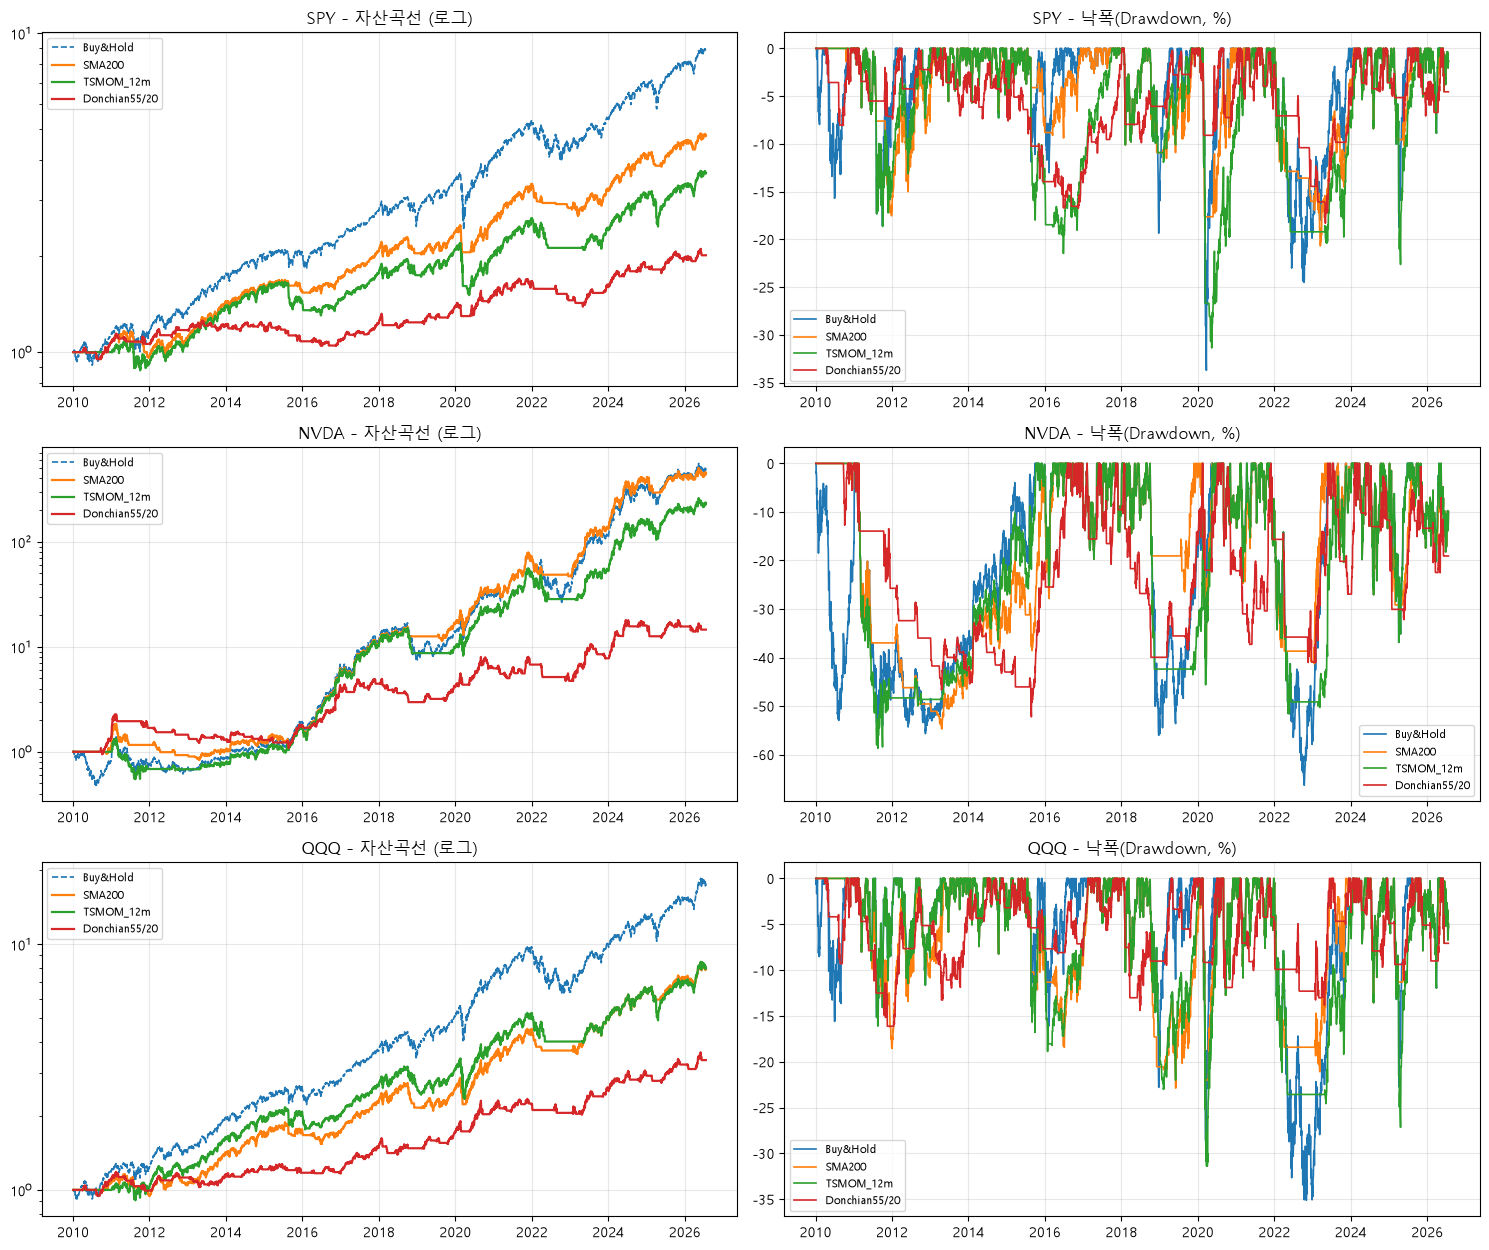

In [6]:
# =====================================================================
# 📈 Cell 6: 자산곡선 & 낙폭 시각화 (대표 자산)
# =====================================================================
def equity_and_dd(df, pos):
    strat, pos_exec = backtest(df['Close'], pos)
    eq = (1 + strat).cumprod()
    dd = eq / eq.cummax() - 1
    return eq, dd

show = [t for t in ['SPY', 'NVDA', 'QQQ'] if t in data]
plot_strats = ['Buy&Hold', 'SMA200', 'TSMOM_12m', 'Donchian55/20']

fig, axes = plt.subplots(len(show), 2, figsize=(15, 4.2*len(show)))
if len(show) == 1:
    axes = axes.reshape(1, 2)
for r, t in enumerate(show):
    df = data[t]
    for name in plot_strats:
        eq, dd = equity_and_dd(df, STRATS[name](df))
        axes[r, 0].plot(eq.index, eq.values, label=name,
                        lw=1.6 if name != 'Buy&Hold' else 1.2,
                        ls='--' if name == 'Buy&Hold' else '-')
        axes[r, 1].plot(dd.index, dd.values*100, label=name, lw=1.2)
    axes[r, 0].set_title(f'{t} - 자산곡선 (로그)'); axes[r, 0].set_yscale('log')
    axes[r, 0].legend(fontsize=8); axes[r, 0].grid(alpha=0.3)
    axes[r, 1].set_title(f'{t} - 낙폭(Drawdown, %)'); axes[r, 1].legend(fontsize=8)
    axes[r, 1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 🧾 결과 해석 가이드 (실행 후 이렇게 읽으세요)

**핵심 질문: 추세추종이 Buy&Hold보다 "위험 대비" 나은가?** (수익 자체가 아니라)

| 지표 | 무엇을 보나 |
|---|---|
| **MaxDD** | 추세추종의 핵심 가치. 하락장에서 현금으로 빠져 낙폭을 줄이는지. **BH보다 얕으면 성공.** |
| **Sharpe / Calmar** | 위험 대비 수익. 평균적으로 BH보다 높으면 규칙이 실제로 기여. |
| **CAGR** | 강한 상승 단일종목(NVDA 등)에선 BH보다 **낮을 수 있음** — 정상. 추세추종은 상투/바닥을 놓치는 대가로 낙폭을 산다. |
| **Trades / TiM** | 회전율. 추세추종은 거래가 적어(수십 회) 비용에 강함. SMA200_3pct가 휩쏘를 더 줄임. |

### 예상되는 정직한 결론
- **지수(SPY·QQQ)·금(GLD)·채권(TLT)**: 추세추종이 MDD를 크게 줄이고 Sharpe를 개선하는 경우가 많음 → **위기 방어(crisis alpha)** 확인.
- **강세 단일종목(NVDA·AAPL)**: 수익(CAGR)은 BH가 이기지만, 낙폭은 추세추종이 방어 → "수익 vs 안정" 트레이드오프.
- 즉 추세추종은 **"더 많이 버는 법"이 아니라 "덜 잃고 오래 살아남는 법"**. 이게 정직한 가치 제안.

### 다음 확장 (원하면)
1. **변동성 타겟팅** — 포지션을 역변동성으로 스케일해 자산 간 리스크 균등화
2. **다자산 포트폴리오** — 위 신호로 여러 자산을 동시 보유(분산) → 개별 자산보다 안정
3. **레짐 필터** — 추세추종을 지수 200일선 위/아래에서만 켜기

> ⚠️ 파라미터는 관습값(200/50/12m/55·20)으로 **고정**했고 이 데이터에 맞추지 않았다. 그래서 과적합이 없다 —
> 이 견고함이 ML 접근 대비 이 방식의 핵심 장점이다. (파라미터를 최적화하기 시작하면 다시 과적합의 함정으로 들어감.)